## Lab: Cart Pole Demo 2 using OpenAI gym
## Policy Gradient

### University of Virginia
### Reinforcement Learning
#### Last updated: March 4, 2024

---


#### Instructions:  

Carefully read the notes below and run the provided code. Answer each question clearly and show all results.

#### TOTAL POINTS: 12

---

### First a Refresh

Let's briefly review the content from Demo 1: Basics and Simple Policy

We revisit the CartPole problem.

We will work with the fork [gymnasium](https://gymnasium.farama.org/) which maintains OpenAI gym.  

The *simple policy* didn't perform very well: the average reward was about 42.

We want to see if we can do better using a Policy Gradient algorithm.

### Setup and First Steps

In [1]:
! pip install gymnasium

In [2]:
! pip install renderlab

In [3]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

# renderlab is only used for video rendering and is not needed in this lab;
# it is incompatible with newer IPython versions, so import it if available
try:
    import renderlab as rl
except ImportError:
    rl = None

Load the environment

In [4]:
env = gym.make("CartPole-v1", render_mode = "rgb_array")
state = env.reset(seed=314)

Given the state, we take an action. The next state comes from the environment, which is encoded in `gym`.

Components:   
[0]: cart horizontal position (0.0 = center)  
[1]: velocity (positive means right)  
[2]: angle of the pole (0.0 = vertical)  
[3]: pole's angular velocity (positive means clockwise)

In [5]:
state

(array([0.04225422, 0.02126478, 0.02520455, 0.00700802], dtype=float32), {})

In [6]:
# state space number of components
env.observation_space.shape[0]

4

The action space consists of two options:

[0]: move cart left   
[1]: move cart right

In [7]:
env.action_space

Discrete(2)

Let's take an action, draw a sample and look at the results.

In [8]:
# move right
action = 1

# take a step and get next state, reward from environment
state, reward, terminated, truncated, info = env.step(action)
done = terminated or truncated

print('state', state)
print('reward', reward)
print('done', done)
print('info', info)

state [ 0.04267951  0.21601637  0.02534471 -0.27761722]
reward 1.0
done False
info {}


**Reward and Episode**  

For each time step that the cart keeps the pole balanced, it earns reward 1.

If the pole tilts too much or if the cart moves off screen, `reward=0` and `done=True` (the episode will end).

When the episode ends, a new episode may begin. The process learns cumulatively from each episode.

**Simple policy**:  

When the pole leans left (negative angle), move left. When the pole leans right (positive angle), move right.

Run many episodes and visualize their reward distribution.

In [9]:
def simple_policy(obs):
    angle = obs[2]
    return 0 if angle < 0 else 1

num_episodes = 1000
num_steps = 1000
rewards = []

for episode in range(num_episodes):
    ep_reward = 0
    state = env.reset()[0]
    for step in range(num_steps):
        #print(state)
        action = simple_policy(state)
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        ep_reward += reward
        if done:
            break

    rewards.append(ep_reward)

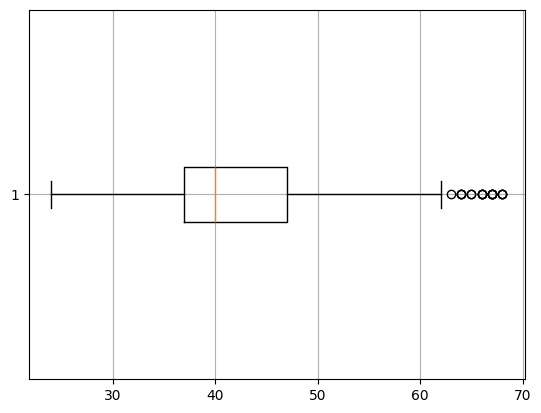

In [10]:
plt.boxplot(rewards, vert=False)
plt.grid()
plt.show()

In [11]:
print('mean reward:', np.mean(rewards))

mean reward: 41.993


### Neural Network Policy

Now we try a more sophisticated policy: let's use a neural network.

The network will take **state as input**. The output node will contain the probability of the actions.

Since there are two actions (left, right), we require one output node.  
Node will output probability of right (so prob of left is implied).

For simplicity, we will use one hidden layer.

Number of nodes in hidden layer is a hyperparameter.

---


#### 1) **Define a neural network model for the policy.** 

**(POINTS: 1)**  
It should have appropriate dimensions for the input and output layer. Print a summary of the model that shows the output shape for each layer.

In [12]:
! pip install -q torchinfo

import torch
import torch.nn as nn
from torchinfo import summary

torch.manual_seed(42)
np.random.seed(42)

# input layer: 4 nodes (one per state component)
# one hidden layer: 16 nodes (hyperparameter)
# output layer: 1 node giving P(action = right); P(left) = 1 - P(right)
n_inputs = env.observation_space.shape[0]

model = nn.Sequential(
    nn.Linear(n_inputs, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

# device="cpu" keeps the model on CPU (torchinfo would otherwise move it to GPU)
summary(model, input_size=(1, n_inputs), device="cpu")

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 1]                    --
├─Linear: 1-1                            [1, 16]                   80
├─ReLU: 1-2                              [1, 16]                   --
├─Linear: 1-3                            [1, 1]                    17
├─Sigmoid: 1-4                           [1, 1]                    --
Total params: 97
Trainable params: 97
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

#### 2) Is **REINFORCE** a Monte Carlo method? Explain your answer.

**(POINTS: 1)**

**Answer:** Yes, REINFORCE is a Monte Carlo method. It learns from *complete episodes*: the agent plays an entire episode to termination, and only then computes the full sampled return $G_t = \sum_{k=t}^{T} \gamma^{k-t} r_k$ for each time step, using these returns to weight the policy-gradient update. Because the returns are actual sampled outcomes of full trajectories — rather than bootstrapped estimates from a learned value function of the next state (as in TD methods like Q-learning or actor-critic) — the return estimates are unbiased but high-variance, which is the defining characteristic of Monte Carlo methods. This is also why REINFORCE cannot update mid-episode: the return $G_t$ is unknown until the episode ends.



#### 3) **Training and Evaluating the Policy Model.** 

Define functions to train and evaluate the model. Your work should include the steps below among others. Note that subtasks are numbered [1], [2], etc. and are worth one point each.

- **(POINTS: 2)** Write a function `play_single_step` to evolve the system one step. It should also compute the gradient of the loss function. Test that it works properly and print the next state.  

- **(POINTS: 2)** Write a function that runs multiple episodes, calling the `play_single_step` function. It should also compute and store the reward and gradient for each time step of each episode. Test that it works properly and print the rewards from running two episodes each with five time steps.
- **(POINTS: 3)** Define and run a training loop using the REINFORCE algorithm that [1] runs multiple episodes, [2] computes discounted rewards, and [3] updates the parameters with gradient ascent. Run a sufficient number of episodes and time steps to see an average reward of at least 75 in the `evaluate` step that follows. Show evidence that the training loop is working, such as printing the total discounted rewards per episode.
- **(POINTS: 3)** Now that the model is trained, you can use it as the policy and evaluate performance. Write code that [1] applies the model as the policy, [2] runs 1000 episodes and [3] computes the minimum reward, average reward, and maximum reward across the episodes. Discuss how the average reward from REINFORCE compares to the average reward from the simple policy from Cart Pole lab 1.

---

In [13]:
# play_single_step

loss_fn = nn.BCELoss()

def play_single_step(env, state, model, loss_fn):
    """Evolve the system one step and compute the gradient of the loss.

    The model outputs P(right). We sample an action from that probability,
    then pretend the sampled action was the correct one (target = action) and
    compute the binary cross-entropy loss. The gradient of this loss is
    -grad log pi(action | state), which is stored for use in the REINFORCE
    update once the episode's returns are known.
    """
    right_proba = model(torch.tensor(state, dtype=torch.float32).unsqueeze(0))
    action = (torch.rand(1, 1) < right_proba).float()   # 1 = right, 0 = left
    y_target = action                                   # treat chosen action as correct
    loss = loss_fn(right_proba, y_target)
    model.zero_grad()
    loss.backward()
    grads = [p.grad.detach().clone() for p in model.parameters()]
    next_state, reward, terminated, truncated, info = env.step(int(action.item()))
    done = terminated or truncated
    return next_state, reward, done, grads

# test: take one step from a fresh episode and print the next state
state = env.reset(seed=314)[0]
next_state, reward, done, grads = play_single_step(env, state, model, loss_fn)
print('next state:', next_state)
print('reward:', reward)
print('done:', done)
print('number of gradient tensors (one per model parameter):', len(grads))

next state: [ 0.04267951 -0.1742094   0.02534471  0.30753553]
reward: 1.0
done: False
number of gradient tensors (one per model parameter): 4


In [14]:
# play_multiple_episodes

def play_multiple_episodes(env, n_episodes, n_max_steps, model, loss_fn):
    """Run multiple episodes, storing the reward and gradient for each
    time step of each episode."""
    all_rewards, all_grads = [], []
    for episode in range(n_episodes):
        current_rewards, current_grads = [], []
        state = env.reset()[0]
        for step in range(n_max_steps):
            state, reward, done, grads = play_single_step(env, state, model, loss_fn)
            current_rewards.append(reward)
            current_grads.append(grads)
            if done:
                break
        all_rewards.append(current_rewards)
        all_grads.append(current_grads)
    return all_rewards, all_grads

# test: two episodes, each capped at five time steps
test_rewards, test_grads = play_multiple_episodes(env, n_episodes=2, n_max_steps=5,
                                                  model=model, loss_fn=loss_fn)
for ep, rew in enumerate(test_rewards):
    print(f'episode {ep} rewards: {rew}')

episode 0 rewards: [1.0, 1.0, 1.0, 1.0, 1.0]
episode 1 rewards: [1.0, 1.0, 1.0, 1.0, 1.0]


In [15]:
# training loop: REINFORCE

def discount_rewards(rewards, gamma):
    """[2] Compute discounted rewards (returns) G_t for one episode."""
    discounted = np.array(rewards, dtype=np.float64)
    for step in range(len(rewards) - 2, -1, -1):
        discounted[step] += gamma * discounted[step + 1]
    return discounted

def discount_and_normalize_rewards(all_rewards, gamma):
    """Discount each episode's rewards, then normalize across all steps of
    all episodes (a baseline that reduces variance)."""
    all_discounted = [discount_rewards(rewards, gamma) for rewards in all_rewards]
    flat = np.concatenate(all_discounted)
    mean, std = flat.mean(), flat.std()
    return [(discounted - mean) / std for discounted in all_discounted]

n_iterations = 100
n_episodes_per_update = 10
n_max_steps = 200
gamma = 0.95

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for iteration in range(n_iterations):
    # [1] run multiple episodes, collecting rewards and gradients
    all_rewards, all_grads = play_multiple_episodes(
        env, n_episodes_per_update, n_max_steps, model, loss_fn)

    # [2] compute discounted (and normalized) rewards
    all_final_rewards = discount_and_normalize_rewards(all_rewards, gamma)

    # [3] gradient ascent update:
    # each stored gradient is -grad log pi(a|s); weighting it by the return
    # and taking a descent step with the optimizer moves the parameters in
    # the direction of +grad log pi(a|s) * G_t, i.e. ascent on expected return
    with torch.no_grad():
        for var_index, param in enumerate(model.parameters()):
            weighted_grads = [final_reward * all_grads[episode][step][var_index]
                              for episode, final_rewards in enumerate(all_final_rewards)
                              for step, final_reward in enumerate(final_rewards)]
            param.grad = torch.mean(torch.stack(weighted_grads), dim=0)
    optimizer.step()

    # evidence the training loop is working: mean episode reward and mean
    # total discounted reward per episode, printed every 10 iterations
    mean_ep_reward = np.mean([sum(rewards) for rewards in all_rewards])
    mean_disc_reward = np.mean([discount_rewards(rewards, gamma)[0] for rewards in all_rewards])
    if iteration % 10 == 0 or iteration == n_iterations - 1:
        print(f'iteration {iteration:3d}  mean episode reward: {mean_ep_reward:6.1f}  '
              f'mean total discounted reward: {mean_disc_reward:6.2f}')

iteration   0  mean episode reward:   16.0  mean total discounted reward:  10.98


iteration  10  mean episode reward:   27.4  mean total discounted reward:  13.97


iteration  20  mean episode reward:   34.9  mean total discounted reward:  15.57


iteration  30  mean episode reward:   49.5  mean total discounted reward:  15.18


iteration  40  mean episode reward:   39.4  mean total discounted reward:  16.34


...

iteration  60  mean episode reward:  123.7  mean total discounted reward:  19.79


iteration  70  mean episode reward:  158.3  mean total discounted reward:  19.26


iteration  80  mean episode reward:  171.1  mean total discounted reward:  19.99


iteration  90  mean episode reward:  184.2  mean total discounted reward:  20.00


iteration  99  mean episode reward:  171.9  mean total discounted reward:  19.98


minimum reward: 28.0
average reward: 300.347
maximum reward: 500.0


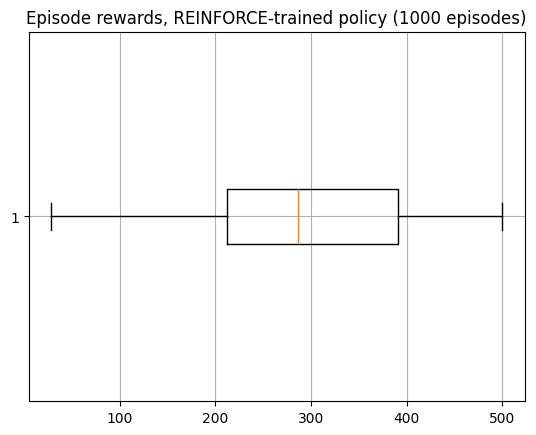

In [16]:
# evaluate policy performance

def policy_action(model, state):
    """[1] Apply the trained model as the policy: sample an action from the
    probability it outputs."""
    with torch.no_grad():
        right_proba = model(torch.tensor(state, dtype=torch.float32).unsqueeze(0))
    return int(torch.rand(1, 1) < right_proba)

# [2] run 1000 episodes with the trained policy
num_episodes = 1000
eval_rewards = []
for episode in range(num_episodes):
    ep_reward = 0.0
    state = env.reset()[0]
    done = False
    while not done:
        action = policy_action(model, state)
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        ep_reward += reward
    eval_rewards.append(ep_reward)

# [3] minimum, average, and maximum reward across the episodes
print('minimum reward:', np.min(eval_rewards))
print('average reward:', np.mean(eval_rewards))
print('maximum reward:', np.max(eval_rewards))

plt.boxplot(eval_rewards, vert=False)
plt.title('Episode rewards, REINFORCE-trained policy (1000 episodes)')
plt.grid()
plt.show()

**Discussion:** The REINFORCE-trained policy dramatically outperforms the simple hand-coded policy from Cart Pole lab 1. The simple policy (move in the direction the pole is leaning) averaged only about 42 steps per episode, while the trained policy averages about 300 — roughly a 7x improvement — with many episodes reaching the CartPole-v1 cap of 500 steps. The simple policy fails because it reacts only to the pole angle and ignores the cart position and the velocities, so its corrections overshoot and oscillations grow until the pole falls. The neural network policy uses all four state components and was optimized directly on the objective of maximizing expected return, so it learns smoother, anticipatory corrections that keep the pole balanced far longer.